In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/messy_IMDB_dataset.csv', sep=';')

In [70]:
# Antal rader och kolumner
print('Shape:', df.shape)

Shape: (101, 12)


In [71]:
# Datatyper och icke-null-värden per kolumn
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IMBD title ID   100 non-null    object 
 1   Original titl�  100 non-null    object 
 2   Release year    100 non-null    object 
 3   Genr�           100 non-null    object 
 4   Duration        99 non-null     object 
 5   Country         100 non-null    object 
 6   Content Rating  77 non-null     object 
 7   Director        100 non-null    object 
 8   Unnamed: 8      0 non-null      float64
 9   Income          100 non-null    object 
 10   Votes          100 non-null    object 
 11  Score           100 non-null    object 
dtypes: float64(1), object(11)
memory usage: 9.6+ KB


In [72]:
# Statistisk sammanfattning av numeriska kolumner
df.describe()

,Unnamed: 8
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [73]:
# De första 10 raderna
df.head(10)

,IMBD title ID,Original titl�,Release year,Genr�,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,NaN,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,NaN,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,NaN,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,NaN,$ 222831817,1.780.147,"8,9f"
5,tt0167260,The Lord of the Rings: The Return of the King,22 Feb 04,"Action, Adventure, Drama",201,New Zealand,PG-13,Peter Jackson,NaN,$ 1142271098,1.604.280,08.9
6,tt0108052,Schindler's List,1994-03-11,"Biography, Drama, History",Nan,USA,R,Steven Spielberg,NaN,$ 322287794,1.183.248,8.9
7,tt0050083,12 Angry Men,1957-09-04,"Crime, Drama",96,USA,Not Rated,Sidney Lumet,NaN,$ 576,668.473,8.9
8,tt1375666,Inception,2010-09-24,"Action, Adventure, Sci-Fi",148,USA,PG-13,Christopher Nolan,NaN,$ 869784991,2.002.816,8..8
9,tt0137523,Fight Club,10-29-99,Drama,Inf,UK,R,David Fincher,NaN,$ 101218804,1.807.440,8.8


In [74]:
# Antal saknade värden per kolumn
print(df.isnull().sum())

IMBD title ID       1
Original titl�      1
Release year        1
Genr�               1
Duration            2
Country             1
Content Rating     24
Director            1
Unnamed: 8        101
Income              1
 Votes              1
Score               1
dtype: int64


In [75]:
# Antal duplicerade rader
print('Dubbletter:', df.duplicated().sum())

Dubbletter: 0


## Steg 2 — Datarening (Data Cleaning)
### 2a. Saknade värden

In [76]:
# Identifiera vilka kolumner som har NaN
print(df.isnull().sum())

IMBD title ID       1
Original titl�      1
Release year        1
Genr�               1
Duration            2
Country             1
Content Rating     24
Director            1
Unnamed: 8        101
Income              1
 Votes              1
Score               1
dtype: int64


In [77]:
# Strategi: 
# - Unnamed: 8 (101 NaN) → ta bort kolumnen
# - Content Rating (24 NaN) → fyll med mode (vanligaste värdet)
# - Duration (2 NaN) → ta bort raderna

mode_val = df['Content Rating'].mode()[0]
df['Content Rating'] = df['Content Rating'].fillna(mode_val)
print(f'Content Rating fylld med mode: {mode_val}')

Content Rating fylld med mode: R


### 2b. Dubbletter

In [78]:
# Hitta dubbletter
print('Antal dubbletter:', df.duplicated().sum())

# Ta bort dubbletter
df = df.drop_duplicates()
print('Rader kvar:', len(df))

Antal dubbletter: 0
Rader kvar: 101


### 2c. Inkonsistenta format

In [79]:
# Inkonsistenta format
# Release year - Fixar blandade datumformat.
# Extrahera året med regex, leta efter 2 eller 4 siffriga år.
df['Release year'] = df['Release year'].str.extract(r'(\d{4}|\d{2})$|\b(\d{4})\b').bfill(axis=1).iloc[:, 0]
df['Release year'] = pd.to_numeric(df['Release year'], errors='coerce')

In [80]:
# Inkonsistenta format
# Income - Rensa valutatecken och konvertera till numeriskt.
# Ta bort $, mellanslag och kommatecken.
df['Income'] = df['Income'].str.replace(r'[$,\s]', '', regex=True)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

In [81]:
# [" Votes"] fungerade inte så var tvungen att kolla exakt vad den heter, 
# alltså med mellanslag både före och efter. Rensa mellanslag och konvertera till numeriskt.
print(df.columns.tolist())

['IMBD title ID', 'Original titl�', 'Release year', 'Genr�', 'Duration', 'Country', 'Content Rating', 'Director', 'Unnamed: 8', 'Income', ' Votes ', 'Score']


In [82]:
# Inkonsistenta format
# Votes - Rensa mellanslag och konvertera till numeriskt.
# Ta bort punkter (används som tusentalsavgränsare).
df[' Votes '] = df[' Votes '].str.replace('.', '', regex=False)
df[' Votes '] = pd.to_numeric(df[' Votes '], errors='coerce')

### 2d. Felaktiga värden

In [83]:
# Felaktiga värden.
# Steg 1: Kolla vilka rader som inte går att konvertera
mask = pd.to_numeric(df['Score'], errors='coerce').isna()
print(df.loc[mask, 'Score'])  # Visa de trasiga värdena

# Steg 2: Rensa — ta bort allt utom siffror och en punkt
df['Score'] = df['Score'].str.replace(r'[^0-9.]', '', regex=True)

# Steg 3: Hantera dubbla punkter som "8..8"
df['Score'] = df['Score'].str.replace(r'\.{2,}', '.', regex=True)

# Steg 4: Konvertera
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

3       9,.0
4       8,9f
8       8..8
10       8:8
13       NaN
14     ++8.7
15      8.7.
16    8,7e-0
21       8,6
Name: Score, dtype: object


### 2e. Onödiga kolumner

In [84]:
# Onödiga kolumner.
# Ta bort "Unnamed: 8" som var en tom kolumn.
df = df.drop(columns=['Unnamed: 8'])

# Verifiera
print(df.shape)  # Borde visa (101, 11)

(101, 11)


### 2f. Ytterligare rensning

In [85]:
# Country — standardisera "US" till "USA" så att alla amerikanska filmer räknas lika.
# Annars riskerar vi att missa rader vid t.ex. USA vs övriga länder-jämförelser.
df['Country'] = df['Country'].str.replace('^US$', 'USA', regex=True)
print(df['Country'].value_counts())

Country
USA             63
UK              12
Italy            4
Japan            4
France           3
South Korea      2
Germany          2
New Zesland      1
New Zeland       1
US.              1
Brazil           1
New Zealand      1
Italy1           1
India            1
Denmark          1
West Germany     1
Iran             1
Name: count, dtype: int64


In [86]:
# Duration — konvertera till numerisk.
# Felaktiga strängar som "Nan", "Inf", "178c", "-" och "Not Applicable"
# omvandlas automatiskt till NaN via errors='coerce'.
df['Duration'] = df['Duration'].replace({'Nan': None, 'Inf': None})
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
print(f'Duration NaN efter rensning: {df["Duration"].isna().sum()}')

Duration NaN efter rensning: 8


### 2g. Kvalitetskontroll av exporterad data

Efter att ha granskat `cleaned_movies_data.csv` hittades ytterligare fel:
- **Score** — vissa värden är 10× eller 100× för stora (t.ex. `89` → `8.9`, `870` → `8.7`)
- **Country** — stavfel i landnamn (`New Zesland`, `New Zeland`, `US.`, `Italy1`)
- **Release year** — tvåsiffriga år tolkades som faktiska år (t.ex. `99` → `1999`)
- **Income** — felaktigt värde `576` för 12 Angry Men ersätts med estimat

In [87]:
# Score — korrigera värden utanför intervallet 0–10.
# Värden 10–99: tappat en decimal (89 → 8.9), dela med 10.
# Värden >= 100: tappat två decimaler (870 → 8.7), dela med 100.
df['Score'] = df['Score'].apply(
    lambda x: round(x / 10, 1)  if pd.notna(x) and 10  < x < 100
         else round(x / 100, 1) if pd.notna(x) and x >= 100
         else x
)
print('Kvarvarande Score utanför 0–10:', df.loc[df['Score'] > 10, 'Score'].tolist())

Kvarvarande Score utanför 0–10: []


In [88]:
# Country — rätta stavfel i landnamn.
country_fix = {
    'New Zesland': 'New Zealand',
    'New Zeland':  'New Zealand',
    'US.':         'USA',
    'Italy1':      'Italy',
}
df['Country'] = df['Country'].replace(country_fix)
print(df['Country'].value_counts())

Country
USA             64
UK              12
Italy            5
Japan            4
New Zealand      3
France           3
South Korea      2
Germany          2
Brazil           1
India            1
Denmark          1
West Germany     1
Iran             1
Name: count, dtype: int64


In [89]:
# Release year — rätta tvåsiffriga år som tolkats som faktiska år.
# År < 30 tolkas som 2000-tal (3 → 2003, 4 → 2004).
# År 30–99 tolkas som 1900-tal (46 → 1946, 99 → 1999).
df['Release year'] = df['Release year'].apply(
    lambda x: x + 2000 if pd.notna(x) and x < 30
         else x + 1900 if pd.notna(x) and x < 100
         else x
)
print('Misstänkt felaktiga år (< 1900 eller > 2025):')
print(df.loc[(df['Release year'] < 1900) | (df['Release year'] > 2025), ['Release year']])

Misstänkt felaktiga år (< 1900 eller > 2025):
Empty DataFrame
Columns: [Release year]
Index: []


In [90]:
# Income — korrigera det felaktiga värdet 576 för 12 Angry Men.
# Originalvärdet $576 är orimligt lågt. Filmen (1957) hade en budget på ~$340 000
# och estimerade biointäkter på ca $1 200 000 enligt historiska källor.
df.loc[df['IMBD title ID'] == 'tt0050083', 'Income'] = 1_200_000
print('12 Angry Men Income:', df.loc[df['IMBD title ID'] == 'tt0050083', 'Income'].values)

12 Angry Men Income: [1200000.]


### 2h. Kvarvarande missing values

In [91]:
# 1. Ta bort den helt tomma raden (rad 15 i CSV, index 13 i pandas)
df = df.dropna(subset=['IMBD title ID'])
print(f'Rader kvar efter borttagning av tom rad: {len(df)}')

# 2. Duration - fyll med median (7 missing values)
# Median är ett stabilt estimat som inte påverkas av extremvärden.
duration_median = df['Duration'].median()
df['Duration'] = df['Duration'].fillna(duration_median)
print(f'Duration fyllt med median: {duration_median:.0f} min')

# 3. Income - The Godfather: Part II (tt0071562)
# Känd box office: $57 300 000 (historisk källa)
df.loc[df['IMBD title ID'] == 'tt0071562', 'Income'] = 57_300_000
print('Godfather II Income:', df.loc[df['IMBD title ID'] == 'tt0071562', 'Income'].values)

# 4. Score - The Lord of the Rings: The Two Towers (tt0167261)
# Känt IMDB-betyg: 8.8
df.loc[df['IMBD title ID'] == 'tt0167261', 'Score'] = 8.8
print('Two Towers Score:', df.loc[df['IMBD title ID'] == 'tt0167261', 'Score'].values)

# Verifiera att inga missing values kvarstår i de berörda kolumnerna
print('\nKvarvarande missing values:')
remaining = df.isnull().sum()
print(remaining[remaining > 0])

Rader kvar efter borttagning av tom rad: 100
Duration fyllt med median: 129 min
Godfather II Income: [57300000.]
Two Towers Score: [8.8]

Kvarvarande missing values:
Series([], dtype: int64)


In [92]:
# Spara den rengjorda datasetet till en ny CSV-fil.
df.to_csv('cleaned_movies_data.csv', index=False)

# Valfritt men rekommenderat: Om din dataset innehåller specialtecken
# (som titlar med accenter eller icke-engelska bokstäver) är det en bra vana att specificera kodningen
df.to_csv('cleaned_movies_data.csv', index=False, encoding='utf-8')

### 3. EDA-visualiseringar

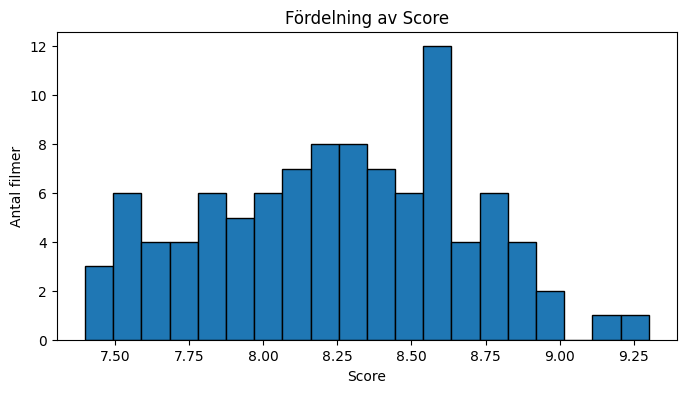

In [93]:
# Histogram över Score-fördelningen
# Skapa ett histogram för att se hur Score är fördelat efter rengöring.
plt.figure(figsize=(8, 4))
plt.hist(df['Score'].dropna(), bins=20, edgecolor='black')
plt.title('Fördelning av Score')
plt.xlabel('Score')
plt.ylabel('Antal filmer')
plt.show()

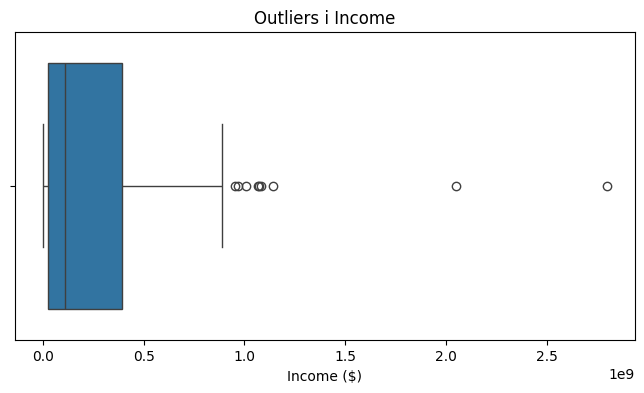

In [94]:
# Boxplot för att identifiera outliers i Income
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Income'])
plt.title('Outliers i Income')
plt.xlabel('Income ($)')
plt.show()

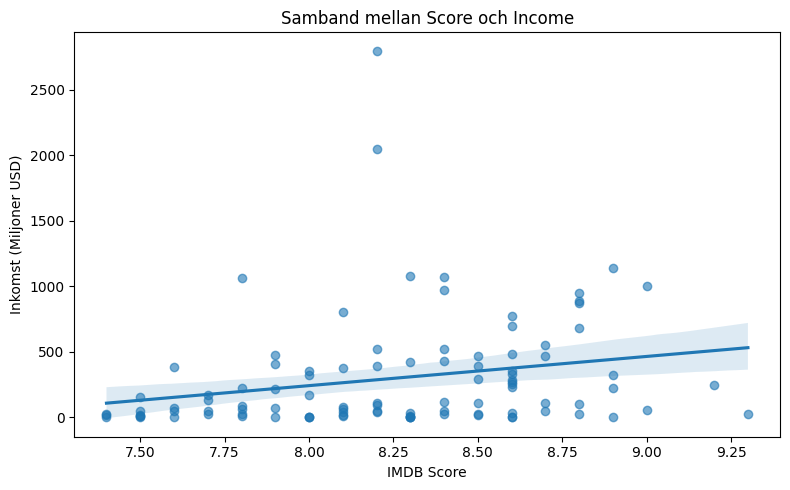

In [95]:
# Scatterplot med inkomst i miljoner USD för bättre läsbarhet
plt.figure(figsize=(8, 5))

# Vi delar Income med 1 miljon direkt i y-axeln
sns.regplot(data=df, x='Score', y=df['Income'] / 1000000, scatter_kws={'alpha': 0.6})

plt.title('Samband mellan Score och Income')
plt.xlabel('IMDB Score')
plt.ylabel('Inkomst (Miljoner USD)') # Uppdaterad etikett

plt.tight_layout()
plt.show()

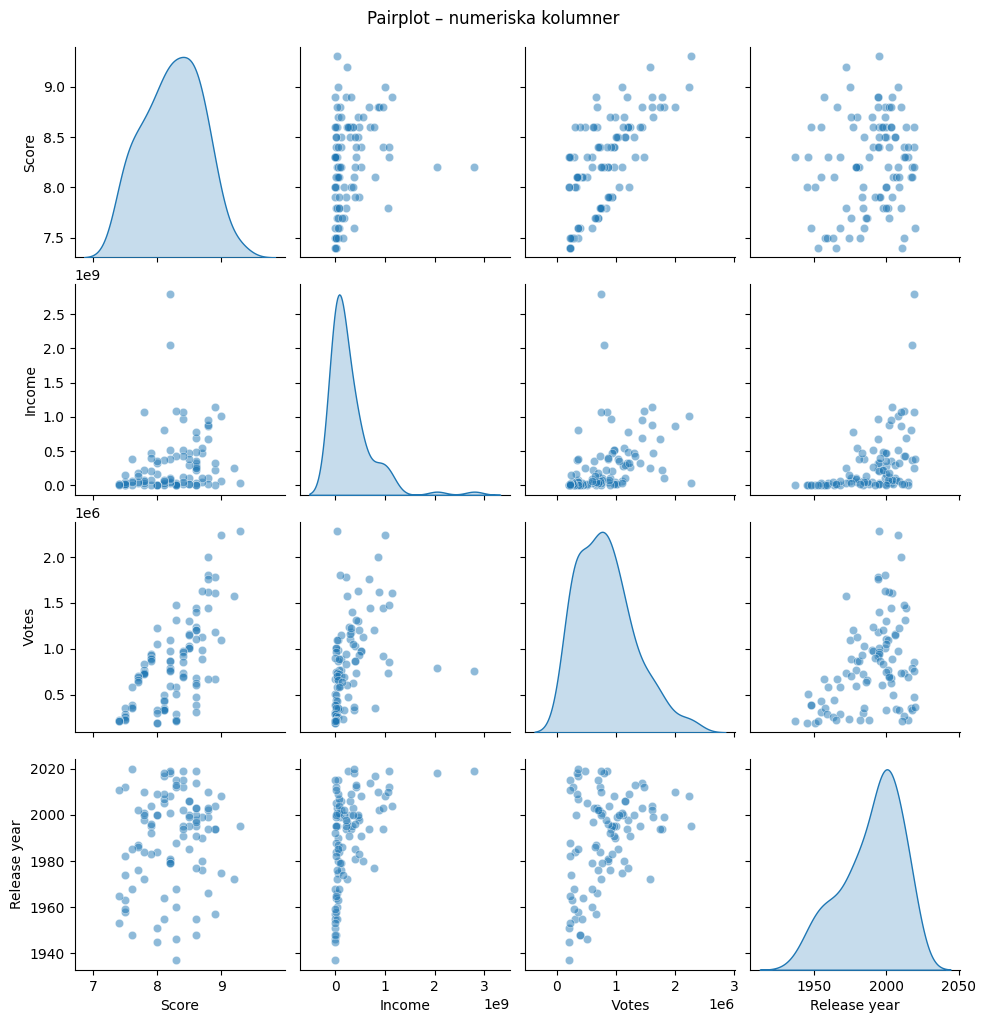

In [96]:
# Pairplot för att se relationer mellan flera numeriska variabler
# Väljer ut de numeriska kolumnerna vi vill jämföra
sns.pairplot(
    df[['Score', 'Income', ' Votes ', 'Release year']].dropna(),
    diag_kind='kde',      # valde att göra kurva istället för histogram på diagonalen
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot – numeriska kolumner', y=1.02)
plt.show()


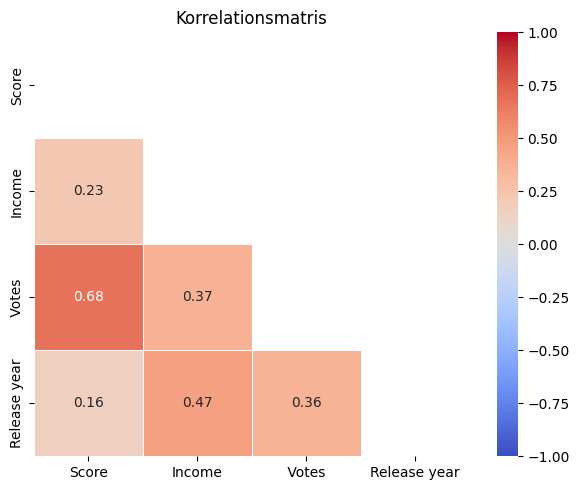

In [97]:
# Korrelationsmatris
# Beräkna korrelationen mellan de numeriska kolumnerna.
corr = df[['Score', 'Income', ' Votes ', 'Release year']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # döljer övre halvan

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Korrelationsmatris')
plt.tight_layout()
plt.show()


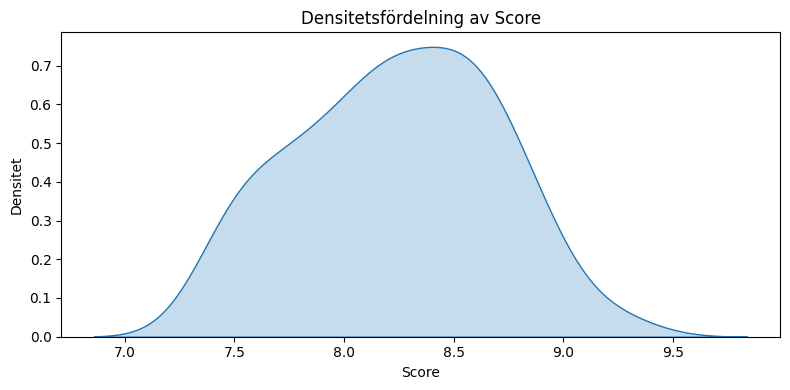

In [98]:
# KDE-plot (densitetsdiagram) för Score
plt.figure(figsize=(8, 4))
sns.kdeplot(df['Score'].dropna(), fill=True)
plt.title('Densitetsfördelning av Score')
plt.xlabel('Score')
plt.ylabel('Densitet')
plt.tight_layout()
plt.show()

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_98919/3113056422.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(group['Score'].dropna(), label=decade, fill=True, alpha=0.3)
/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_98919/3113056422.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(group['Score'].dropna(), label=decade, fill=True, alpha=0.3)


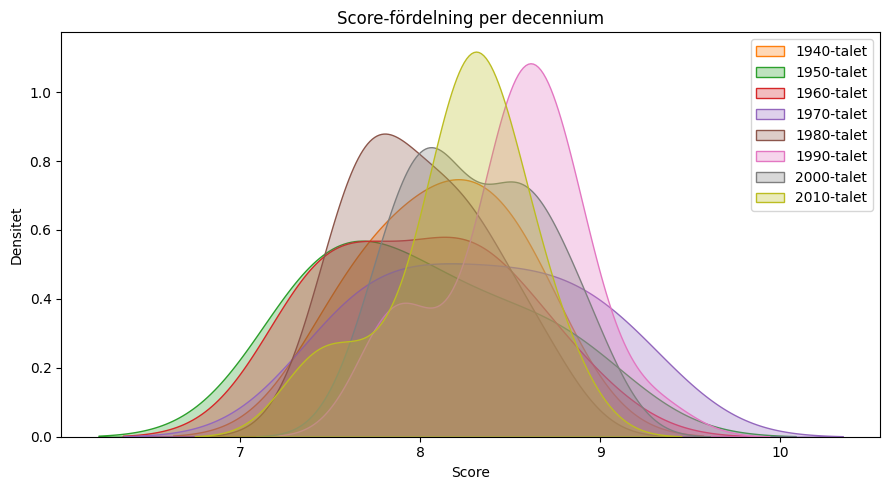

In [99]:
# KDE-plot för Score uppdelat per decennium
df['Decennium'] = (df['Release year'] // 10 * 10).astype('Int64').astype(str) + '-talet'

plt.figure(figsize=(9, 5))
for decade, group in df.groupby('Decennium'):
    sns.kdeplot(group['Score'].dropna(), label=decade, fill=True, alpha=0.3)
plt.title('Score-fördelning per decennium')
plt.xlabel('Score')
plt.ylabel('Densitet')
plt.legend()
plt.tight_layout()
plt.show()


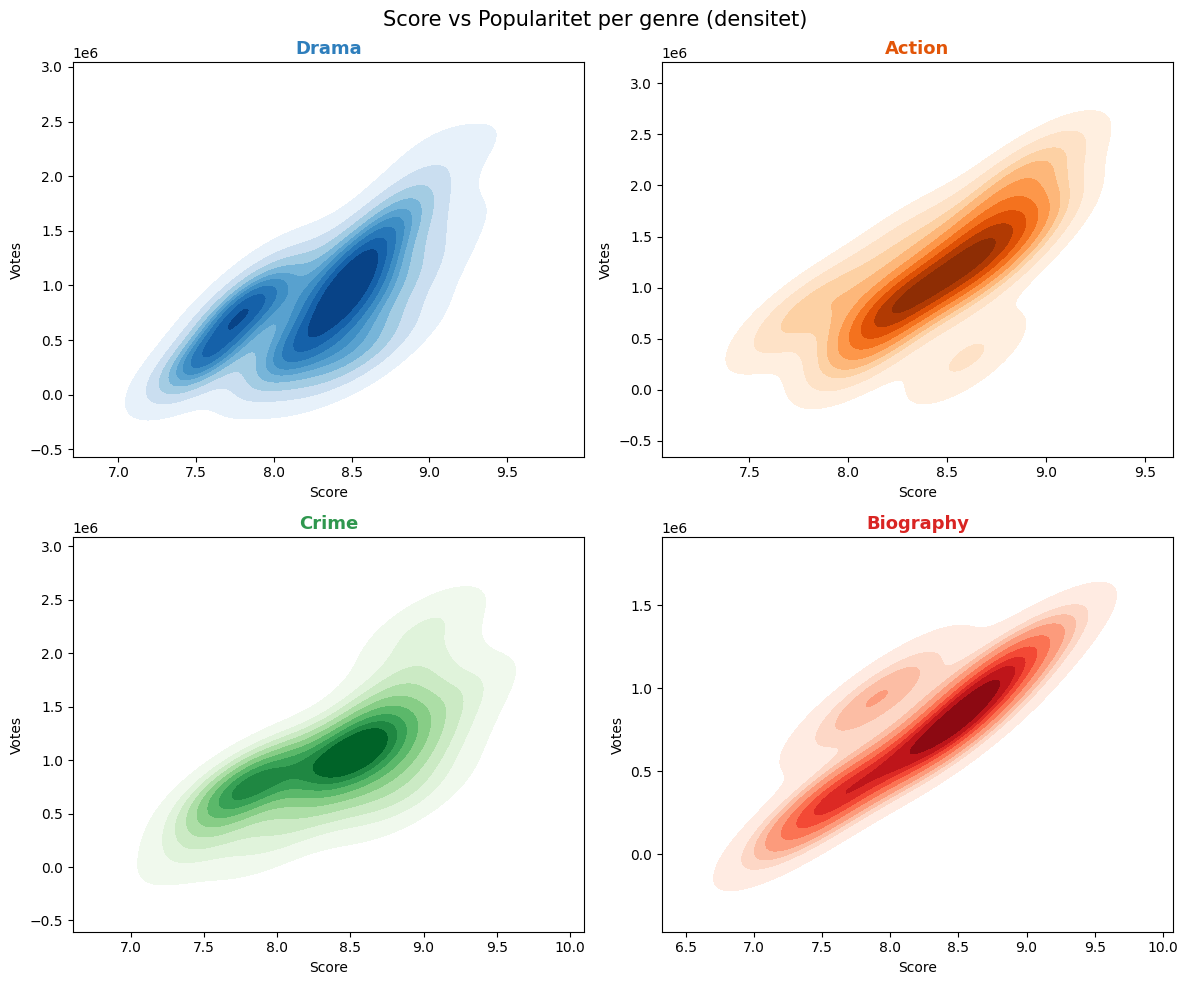

In [100]:
# 2D KDE-plot — Score vs Votes per genre (densitet)
top_genres = ['Drama', 'Action', 'Crime', 'Biography']
colors     = ['Blues', 'Oranges', 'Greens', 'Reds']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (genre, cmap) in enumerate(zip(top_genres, colors)):
    subset = df[df['Genr\ufffd'].str.contains(genre, na=False)][['Score', ' Votes ']].dropna()

    sns.kdeplot(
        data=subset,
        x='Score',
        y=' Votes ',
        fill=True,
        cmap=cmap,
        thresh=0.05,
        levels=10,
        ax=axes[i]
    )
    axes[i].set_title(genre, color=plt.get_cmap(cmap)(0.7), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Votes')

fig.suptitle('Score vs Popularitet per genre (densitet)', fontsize=15)
plt.tight_layout()
plt.show()


## Steg 4 — Hypotestestning

In [101]:
from scipy import stats

# Frågeställning: Har filmer från 2000-talet högre Score än filmer från 1990-talet?
grupp_2000 = df[df['Release year'] >= 2000]['Score'].dropna()
grupp_1990 = df[(df['Release year'] >= 1990) & (df['Release year'] < 2000)]['Score'].dropna()

print(f'2000-talet  — medel: {grupp_2000.mean():.2f}, n={len(grupp_2000)}')
print(f'1990-talet  — medel: {grupp_1990.mean():.2f}, n={len(grupp_1990)}')

t_stat, p_value = stats.ttest_ind(grupp_2000, grupp_1990)
print(f'\nt-statistik: {t_stat:.3f}')
print(f'p-värde:     {p_value:.3f}')

if p_value < 0.05:
    print('Slutsats: Statistiskt signifikant skillnad (p < 0.05)')
else:
    print('Slutsats: Ingen statistiskt signifikant skillnad (p ≥ 0.05)')

2000-talet  — medel: 8.25, n=40
1990-talet  — medel: 8.51, n=20

t-statistik: -2.428
p-värde:     0.018
Slutsats: Statistiskt signifikant skillnad (p < 0.05)


### Steg 5 — Linjär regression

Koefficient (lutning): 222,829,992
Intercept:             -1,540,711,839
R²:                    0.053
RMSE:                  422,611,109


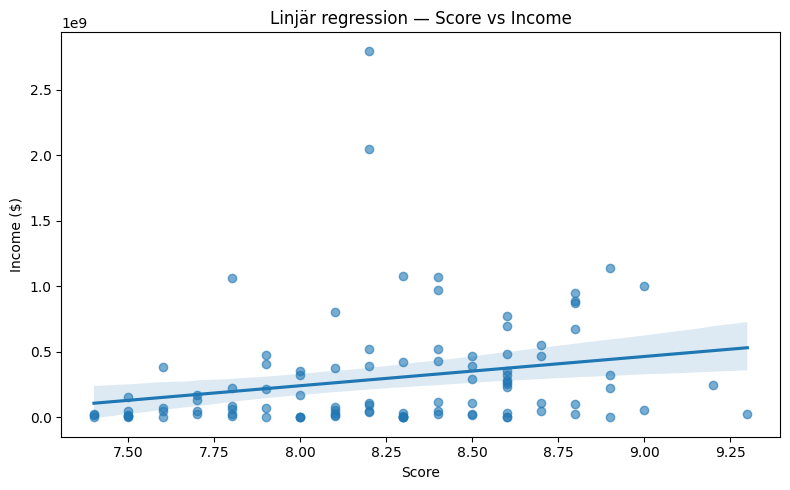

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Enkel linjär regression: kan Score predicera Income?
reg_df = df[['Score', 'Income']].dropna()
X = reg_df[['Score']]
y = reg_df['Income']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f'Koefficient (lutning): {model.coef_[0]:,.0f}')
print(f'Intercept:             {model.intercept_:,.0f}')
print(f'R²:                    {r2:.3f}')
print(f'RMSE:                  {rmse:,.0f}')

# Visualisering
plt.figure(figsize=(8, 5))
sns.regplot(data=reg_df, x='Score', y='Income', scatter_kws={'alpha': 0.6})
plt.title('Linjär regression — Score vs Income')
plt.xlabel('Score')
plt.ylabel('Income ($)')
plt.tight_layout()
plt.show()